## CLUSTERING

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score



df = pd.read_csv("../data/processed/cleaned_data.csv")

# Drop churn (target) and customer_id from clustering features
X_cluster = df.drop(columns=["churn", "customer_id"], errors="ignore")

# One hot encode the remaining features
X_cluster = pd.get_dummies(X_cluster, drop_first=True)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print(f"Clustering feature matrix shape: {X_scaled.shape}")
print("Data successfully loaded and scaled without using the churn target!")

Clustering feature matrix shape: (7043, 35)
Data successfully loaded and scaled without using the churn target!


range(2, 11)
For k=2, Silhouette Score = 0.3036
For k=3, Silhouette Score = 0.2176
For k=4, Silhouette Score = 0.2310
For k=5, Silhouette Score = 0.2025
For k=6, Silhouette Score = 0.1915
For k=7, Silhouette Score = 0.1823
For k=8, Silhouette Score = 0.1231
For k=9, Silhouette Score = 0.1240
For k=10, Silhouette Score = 0.1238


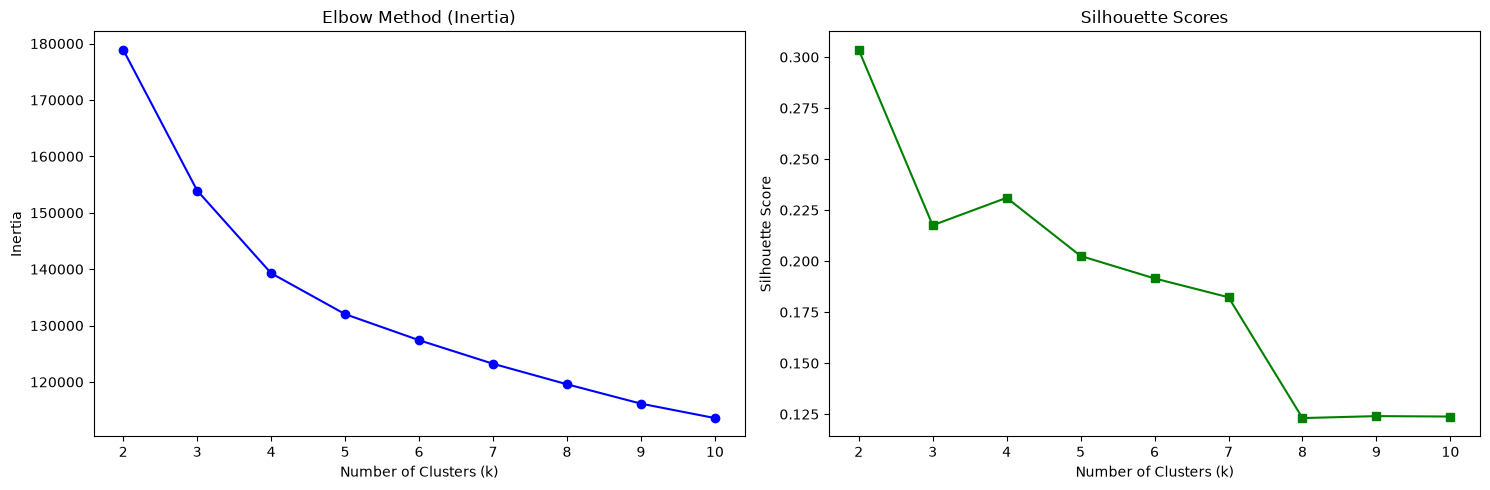

Elbow and Silhouette plot saved successfully.


<Figure size 640x480 with 0 Axes>

In [35]:
# Optimal Cluster Selection (Elbow Method & Silhouette Score)
inertia = []
silhouette_scores = []
K_range = range(2, 11)

print(K_range)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    inertia.append(kmeans.inertia_)
    sil_score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(sil_score)
    print(f"For k={k}, Silhouette Score = {sil_score:.4f}")
    
# Plotting Elbow and Silhouette graphs
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Elbow Curve
axes[0].plot(K_range, inertia, marker='o', color='b')
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

# Silhouette Score Curve
axes[1].plot(K_range, silhouette_scores, marker='s', color='g')
axes[1].set_title('Silhouette Scores')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

# Save Elbow & Silhouette figure
output_dir = Path("../artifacts/figures/clustering")
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / "elbow_silhouette.png", dpi=300, bbox_inches="tight")
print("Elbow and Silhouette plot saved successfully.")

In [36]:
# Comprehensive Multi-Algorithm Benchmark (K-Means, Agglomerative, DBSCAN)
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

evaluation_results = []

# Evaluate K-Means & Agglomerative for k=2 to 5
for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    evaluation_results.append({
        "Model": f"K-Means (k={k})",
        "Silhouette": silhouette_score(X_scaled, km.labels_),
        "Calinski-Harabasz": calinski_harabasz_score(X_scaled, km.labels_),
        "Davies-Bouldin": davies_bouldin_score(X_scaled, km.labels_)
    })
    
    agg = AgglomerativeClustering(n_clusters=k).fit(X_scaled)
    evaluation_results.append({
        "Model": f"Agglomerative (k={k})",
        "Silhouette": silhouette_score(X_scaled, agg.labels_),
        "Calinski-Harabasz": calinski_harabasz_score(X_scaled, agg.labels_),
        "Davies-Bouldin": davies_bouldin_score(X_scaled, agg.labels_)
    })

# Evaluate DBSCAN (density-based approach)
dbscan = DBSCAN(eps=3.5, min_samples=10).fit(X_scaled)
db_labels = dbscan.labels_
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)

if n_clusters_db > 1:
    valid_mask = db_labels != -1
    evaluation_results.append({
        "Model": f"DBSCAN (Clusters: {n_clusters_db}, Noise: {n_noise})",
        "Silhouette": silhouette_score(X_scaled[valid_mask], db_labels[valid_mask]),
        "Calinski-Harabasz": calinski_harabasz_score(X_scaled[valid_mask], db_labels[valid_mask]),
        "Davies-Bouldin": davies_bouldin_score(X_scaled[valid_mask], db_labels[valid_mask])
    })

df_eval = pd.DataFrame(evaluation_results)
display(df_eval)

,Model,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,K-Means (k=2),0.303587,2660.229838,1.219635
1,Agglomerative (k=2),0.304633,2646.389746,1.228242
2,K-Means (k=3),0.217560,2116.723480,1.845312
3,Agglomerative (k=3),0.207784,2008.285029,1.816860
4,K-Means (k=4),0.231036,1806.256680,1.721417
5,Agglomerative (k=4),0.229027,1760.024008,1.723009
6,K-Means (k=5),0.202537,1525.603879,2.007910
7,Agglomerative (k=5),0.199588,1508.536994,2.005129
8,"DBSCAN (Clusters: 9, Noise: 1374)",0.117583,453.706508,1.433946


PCA cluster plot successfully saved to: ../artifacts/figures/clustering/pca_clusters.png


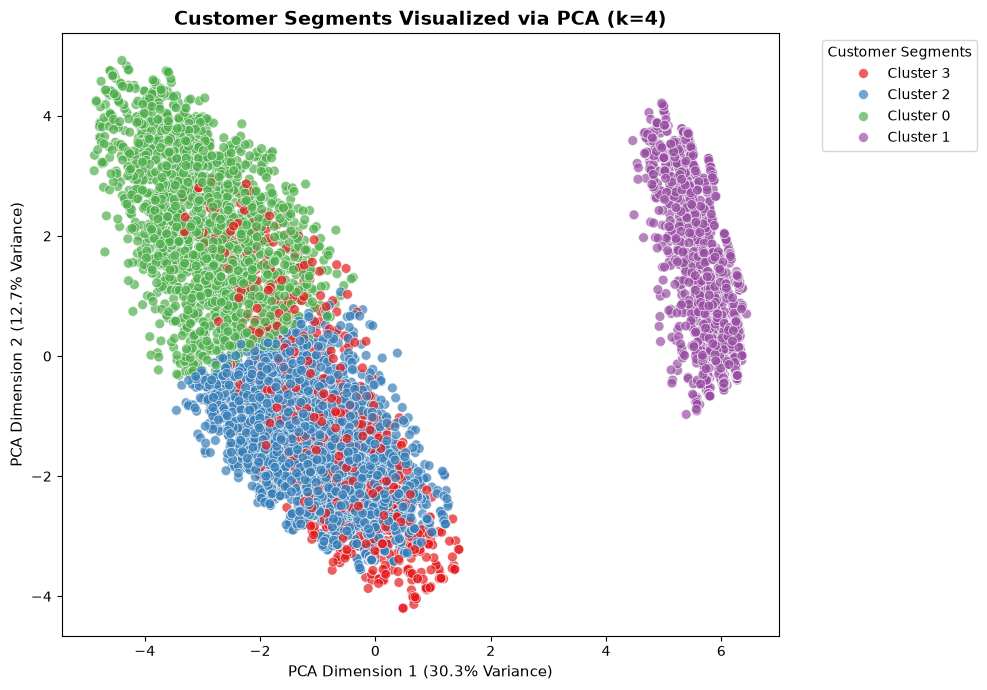

In [37]:
# Fit Final K-Means (k=4), Apply PCA, and Save Visualization
from pathlib import Path

# Fit final K-Means with k=4
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to our working dataframe for profiling
df["cluster"] = cluster_labels

# Dimensionality Reduction via PCA (2 components for 2D plotting)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Create a plotting DataFrame
df_pca = pd.DataFrame(X_pca, columns=["PCA1", "PCA2"])
df_pca["Cluster"] = [f"Cluster {c}" for c in cluster_labels]

# Plotting and saving the figure
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x="PCA1", y="PCA2", 
    hue="Cluster", 
    data=df_pca, 
    palette="Set1", 
    alpha=0.7, 
    s=50
)

plt.title(f"Customer Segments Visualized via PCA (k={optimal_k})", fontsize=14, fontweight="bold")
plt.xlabel(f"PCA Dimension 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)", fontsize=11)
plt.ylabel(f"PCA Dimension 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)", fontsize=11)
plt.legend(title="Customer Segments", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

# Save figure to artifacts
output_dir = Path("../artifacts/figures/clustering")
output_dir.mkdir(parents=True, exist_ok=True)
plot_path = output_dir / "pca_clusters.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
print(f"PCA cluster plot successfully saved to: {plot_path}")

plt.show()